# How many independent evaluations axioms are there?

This notebook counts how many independent evaluation axioms there are for an ensemble of $N$ classifiers. There are three sets of equations that define the logic of unsupervised evaluation for classifiers. The first two sets of equations (called an ideal in algebraic geometry) define the set of all possible evaluations for a test of size $Q$. These are the evaluations before we observe any test results.

The third set of equations use the counts of how the classifiers agreed and disagreed on the test. For a classification test with $R$ possible labels, there are $R^N$ ways that classifiers can do this when labeling a single item. Adding the third set of equations to the first two then gives the restricted set of the group evaluations that are **logically consistent** with the test results.

We will go over these set of equations and use linear algebra to count how many of these axioms are independent. Note that this is very different from asking if the classifiers where independent in their errors during a test. That is a different independence -- classifier independence. This notebook explores **axiom independence**.

In [1]:
import itertools, random
import sympy
from IPython.display import display,Math,Latex, HTML
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import ntqr
import ntqr.raxioms
sympy.init_session()
sympy.init_printing(latex_mode='inline',fontsize='14pt',print_builtin=True, use_unicode=True)

IPython console for SymPy 1.14.0 (Python 3.13.9-64-bit) (ground types: gmpy)

These commands were executed:
>>> from sympy import *
>>> x, y, z, t = symbols('x y z t')
>>> k, m, n = symbols('k m n', integer=True)
>>> f, g, h = symbols('f g h', cls=Function)
>>> init_printing()

Documentation can be found at https://docs.sympy.org/1.14.0/



## The simplex axioms

The **simplex axioms** are shown here. These are the equations stating that the count of all events conditioned on a true label must be equal to the appearance of that label in the answer key. This is a normalization of events statement. Given R labels and N classifiers making decisions, we have a complete description of their decision events ($R^N$ of them). The count of a label, $\ell$ , in the answer key is denoted by $Q_{\ell}$.

There are many of these simplex equations for an ensemble of size $N$, one for every subset of them and for every label. Why do we need all these spaces to talk about the group evaluations for the classifiers? What is a **group evaluation**? In essence, we want to know the partition of any decision event by true label. But we cannot just solve for these variables since it will admit too many partitions by true label. Some of these partitions will not marginalize properly when we look at subsets of the classifiers.

Let's count the simplex axioms,

\begin{equation}
\sum_{l=1}^{R} \sum_{m=1}^{N} \binom{N}{m} = R \left(2^N - 1 \right)
\end{equation}

Assuming that the answer key is fixed (not a variable), the number of variables in these equations is larger,

\begin{equation}
\sum_{l=1}^{R} \sum_{m=1}^{N} R^m \binom{N}{m} = R \left( (1+R)^N - 1 \right)
\end{equation}

Let's test the count of the variables

In [2]:
# This class is being deprecated in the upcoming version
labels = ('a','b','c')
classifiers = ('i','j','k')
mVars = ntqr.statistics.MClassifiersVariables(labels, classifiers)
mVars

MClassifiersVariables(('a', 'b', 'c'),('i', 'j', 'k'))

In [3]:
nVars = sum(len([value for value in label_vars.values()]) for msubset,decisions_by_true_label in mVars.label_responses.items()
   for decisions, label_vars in decisions_by_true_label.items())
nVars == 3*((1+3)**3 - 1)

True

In [4]:
3*((4)**3-1)

In [5]:
simplexAxioms = ntqr.raxioms.ClassifiersSimplexAxioms(('a','b','c'),('i','j'))
simplexAxioms.axioms

mappingproxy({'a': -Qₐ + R_{a_{i},a_{j},a} + R_{a_{i},b_{j},a} + R_{a_{i},c_{j},a} + R_{b_{i},a_{ ↪

↪ j},a} + R_{b_{i},b_{j},a} + R_{b_{i},c_{j},a} + R_{c_{i},a_{j},a} + R_{c_{i} ↪

↪ ,b_{j},a} + R_{c_{i},c_{j},a},
              'b': -Q_b + R_{a_{i},a_{j},b} + R_{a_{i},b_{j},b} + R_{a_{i},c_{j},b} + R_{b_{i},a_ ↪

↪ {j},b} + R_{b_{i},b_{j},b} + R_{b_{i},c_{j},b} + R_{c_{i},a_{j},b} + R_{c_{i ↪

↪ },b_{j},b} + R_{c_{i},c_{j},b},
              'c': -Q_c + R_{a_{i},a_{j},c} + R_{a_{i},b_{j},c} + R_{a_{i},c_{j},c} + R_{b_{i},a_ ↪

↪ {j},c} + R_{b_{i},b_{j},c} + R_{b_{i},c_{j},c} + R_{c_{i},a_{j},c} + R_{c_{i ↪

↪ },b_{j},c} + R_{c_{i},c_{j},c}})

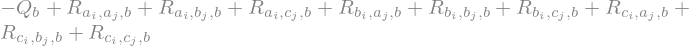

In [6]:
simplexAxioms.axioms['b']

In [7]:
rVars=ntqr.statistics.ClassifiersResponseVariables(('a','b','c'),('i','j')).label_responses
rVars['b']

{('a', 'a'): R_{a_{i},a_{j},b},
 ('a', 'b'): R_{a_{i},b_{j},b},
 ('a', 'c'): R_{a_{i},c_{j},b},
 ('b', 'a'): R_{b_{i},a_{j},b},
 ('b', 'b'): R_{b_{i},b_{j},b},
 ('b', 'c'): R_{b_{i},c_{j},b},
 ('c', 'a'): R_{c_{i},a_{j},b},
 ('c', 'b'): R_{c_{i},b_{j},b},
 ('c', 'c'): R_{c_{i},c_{j},b}}